
MODULE 1 : DATA INGESTION

FIRST 5 ROWS
                         Data  Temperatura  Humidade
0  06/01/2023 19:00:00 -03:00         27.2      82.6
1  06/01/2023 20:00:00 -03:00         27.0      83.0
2  06/01/2023 21:00:00 -03:00         27.0      83.0
3  06/01/2023 22:00:00 -03:00         26.7      83.9
4  06/01/2023 23:00:00 -03:00         26.5      85.4

DATASET INFO
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1226 entries, 2023-01-06 19:00:00-03:00 to 2023-04-26 04:00:00-03:00
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperatura  1226 non-null   float64
 1   Humidade     1226 non-null   float64
dtypes: float64(2)
memory usage: 28.7 KB
None

STATISTICAL SUMMARY
       Temperatura     Humidade
count  1226.000000  1226.000000
mean     27.484176    83.544698
std       2.533771    10.135873
min      20.400000    61.600000
25%      25.800000    74.900000
50%      27.400000    82.650000
75%      29.90

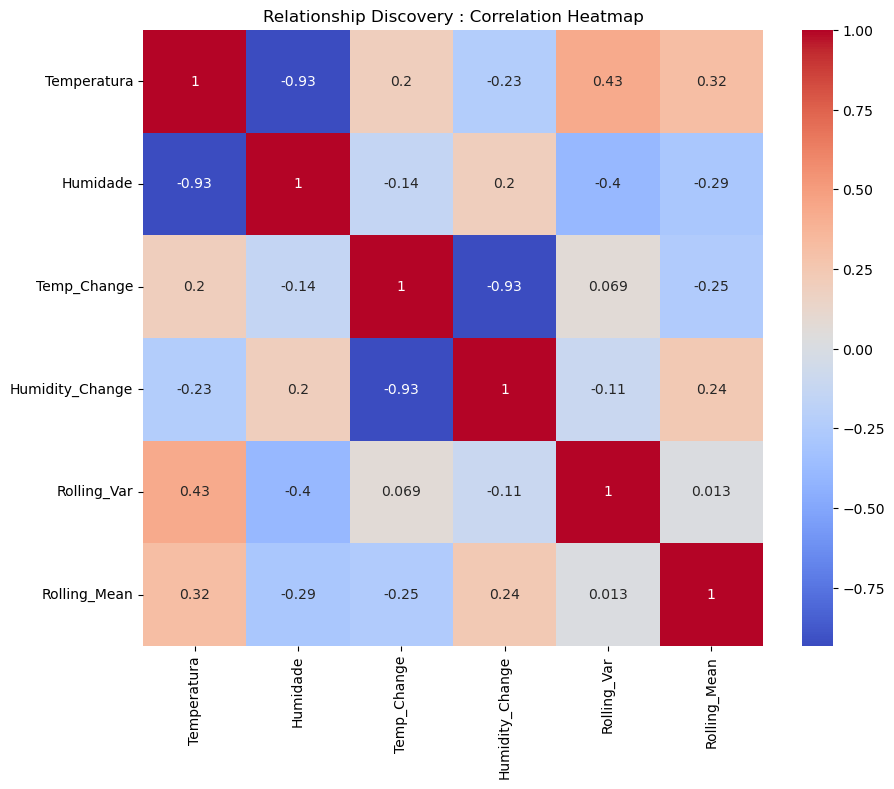


MODULE 4 : UNSUPERVISED DISCOVERY

CALCULATING ELBOW METHOD


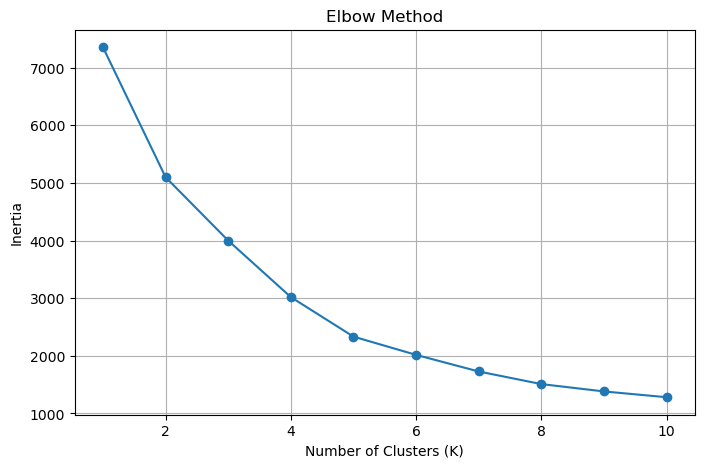


GROUP DISTRIBUTION
Cluster_Label
Rapid Change Zone    529
Stable Weather       379
Humid Region         318
Name: count, dtype: int64

SILHOUETTE SCORE
0.32129913981244845

MODULE 5 : ANOMALY DETECTION

ANOMALY THRESHOLD
32.55171771696812

ANOMALY DISTRIBUTION
Anomaly
0    1224
1       2
Name: count, dtype: int64

MODULE 6 : RANDOM FOREST

MODEL TRAINED SUCCESSFULLY

PREDICTIONS COMPLETED

MODULE 7 : MODEL EVALUATION

MODEL ACCURACY
100.00%

CONFUSION MATRIX
[[246]]

CLASSIFICATION REPORT
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       246
     Anomaly       0.00      0.00      0.00         0

    accuracy                           1.00       246
   macro avg       0.50      0.50      0.50       246
weighted avg       1.00      1.00      1.00       246


MODULE 8 : VISUALIZATION


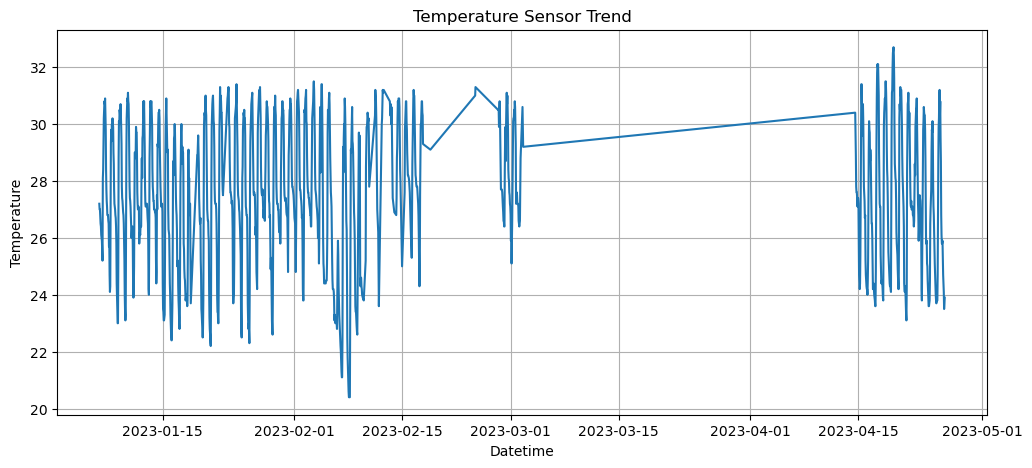

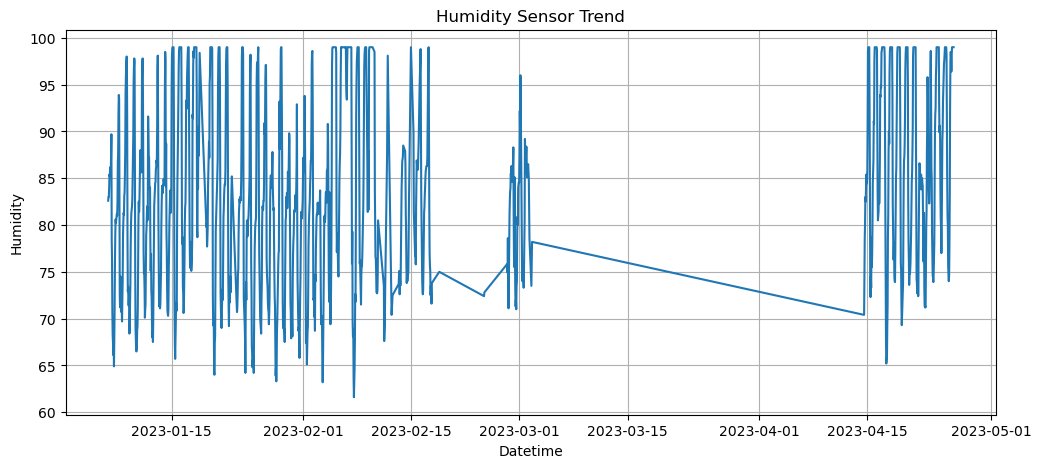

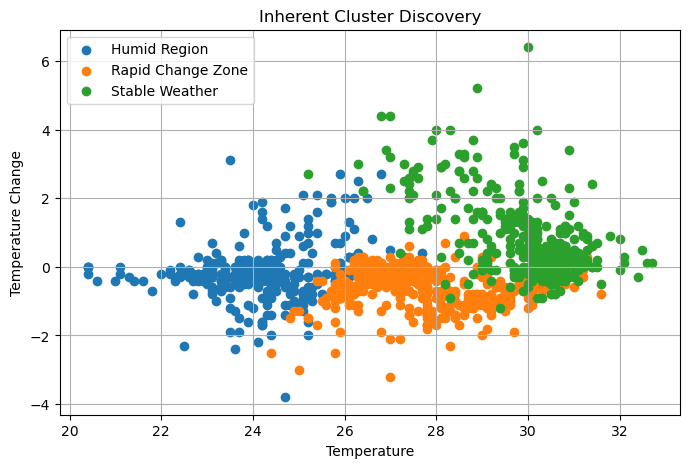

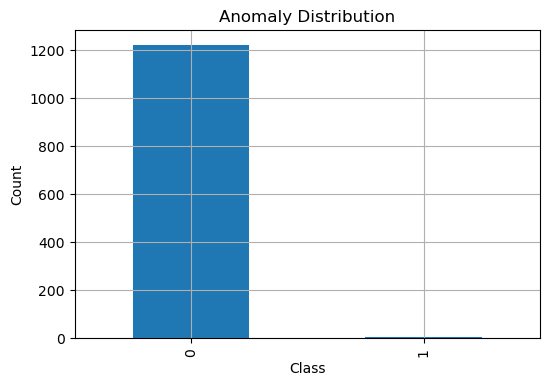

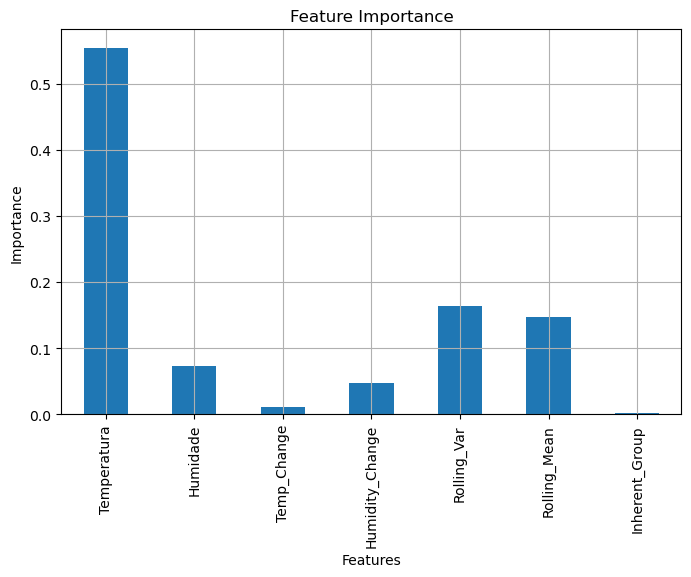


MODULE 9 : MODEL SERIALIZATION

MODEL SAVED SUCCESSFULLY

FILE : weather_mining_model.pkl

FINAL MINED DATA SAVED

PR_28 PRACTICAL COMPLETED


In [2]:
# ==========================================
# PR_28
# DATA MINING TECHNIQUES
# WEATHER STATION DATASET
# FULL INDUSTRIAL WORKFLOW
# ==========================================

# ==========================================
# FIX WARNINGS
# ==========================================

import os
import warnings

os.environ["OMP_NUM_THREADS"] = "5"

warnings.filterwarnings("ignore")

# ==========================================
# IMPORT LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (

    classification_report,

    confusion_matrix,

    accuracy_score,

    silhouette_score

)

# ==========================================
# MODULE 1 :
# DATA INGESTION
# ==========================================

print("\n===================================")
print("MODULE 1 : DATA INGESTION")
print("===================================")

"""
DEFINITION:
Data ingestion converts raw weather
sensor data into analytical format.
"""

# ---------- LOAD DATASET ----------

df = pd.read_csv(
    "B2K weather station.csv"
)

print("\nFIRST 5 ROWS")
print(df.head())

# ---------- DATETIME CONVERSION ----------

df['Data'] = pd.to_datetime(

    df['Data'],

    dayfirst=True,

    errors='coerce'

)

# ---------- REMOVE INVALID DATES ----------

df = df.dropna(
    subset=['Data']
)

# ---------- SET INDEX ----------

df = df.set_index('Data')

df = df.sort_index()

# ---------- CONVERT NUMERIC ----------

df['Temperatura'] = pd.to_numeric(

    df['Temperatura'],

    errors='coerce'

)

df['Humidade'] = pd.to_numeric(

    df['Humidade'],

    errors='coerce'

)

# ---------- REMOVE INVALID VALUES ----------

df = df.dropna(
    subset=[
        'Temperatura',
        'Humidade'
    ]
)

# ---------- KEEP REQUIRED COLUMNS ----------

df = df[[
    'Temperatura',
    'Humidade'
]]

print("\nDATASET INFO")
print(df.info())

print("\nSTATISTICAL SUMMARY")
print(df.describe())


# ==========================================
# MODULE 2 :
# FEATURE ENGINEERING
# ==========================================

print("\n===================================")
print("MODULE 2 : FEATURE ENGINEERING")
print("===================================")

"""
DEFINITION:
Feature engineering extracts hidden
behavioral patterns from raw data.
"""

# ---------- TEMPERATURE CHANGE ----------

df['Temp_Change'] = (

    df['Temperatura']

    .diff()

    .fillna(0)

)

# ---------- HUMIDITY CHANGE ----------

df['Humidity_Change'] = (

    df['Humidade']

    .diff()

    .fillna(0)

)

# ---------- ROLLING VARIANCE ----------

df['Rolling_Var'] = (

    df['Temperatura']

    .rolling(window=10)

    .var()

    .fillna(0)

)

# ---------- ROLLING MEAN ----------

df['Rolling_Mean'] = (

    df['Temperatura']

    .rolling(window=10)

    .mean()

    .fillna(0)

)

print("\nFEATURES CREATED SUCCESSFULLY")


# ==========================================
# MODULE 3 :
# CORRELATION ANALYSIS
# ==========================================

print("\n===================================")
print("MODULE 3 : CORRELATION ANALYSIS")
print("===================================")

"""
DEFINITION:
Correlation analysis discovers
relationships between variables.
"""

# ---------- CORRELATION MATRIX ----------

corr_matrix = df.corr()

print("\nCORRELATION MATRIX")
print(corr_matrix)

# ---------- HEATMAP ----------

plt.figure(figsize=(10,8))

sns.heatmap(

    corr_matrix,

    annot=True,

    cmap='coolwarm'

)

plt.title(
    "Relationship Discovery : Correlation Heatmap"
)

plt.show()


# ==========================================
# MODULE 4 :
# UNSUPERVISED CLUSTERING
# ==========================================

print("\n===================================")
print("MODULE 4 : UNSUPERVISED DISCOVERY")
print("===================================")

"""
DEFINITION:
K-Means discovers hidden
weather operational groups.
"""

# ---------- FEATURE MATRIX ----------

X_cluster = df[[

    'Temperatura',

    'Humidade',

    'Temp_Change',

    'Humidity_Change',

    'Rolling_Var',

    'Rolling_Mean'

]]

# ---------- STANDARDIZATION ----------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    X_cluster
)

# ==========================================
# ELBOW METHOD
# ==========================================

print("\nCALCULATING ELBOW METHOD")

inertia_scores = []

K_range = range(1, 11)

for k in K_range:

    model = KMeans(

        n_clusters=k,

        init='k-means++',

        n_init=10,

        random_state=42

    )

    model.fit(X_scaled)

    inertia_scores.append(
        model.inertia_
    )

# ---------- ELBOW GRAPH ----------

plt.figure(figsize=(8,5))

plt.plot(

    K_range,

    inertia_scores,

    marker='o'

)

plt.xlabel("Number of Clusters (K)")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.grid(True)

plt.show()

# ---------- FINAL KMEANS ----------

kmeans = KMeans(

    n_clusters=3,

    init='k-means++',

    n_init=10,

    random_state=42

)

# ---------- ASSIGN CLUSTERS ----------

df['Inherent_Group'] = (
    kmeans.fit_predict(X_scaled)
)

# ---------- LABEL CLUSTERS ----------

cluster_names = {

    0: 'Stable Weather',

    1: 'Humid Region',

    2: 'Rapid Change Zone'

}

df['Cluster_Label'] = (

    df['Inherent_Group']

    .map(cluster_names)

)

print("\nGROUP DISTRIBUTION")

print(
    df['Cluster_Label']
    .value_counts()
)

# ---------- SILHOUETTE SCORE ----------

score = silhouette_score(

    X_scaled,

    df['Inherent_Group']

)

print("\nSILHOUETTE SCORE")
print(score)


# ==========================================
# MODULE 5 :
# ANOMALY DETECTION
# ==========================================

print("\n===================================")
print("MODULE 5 : ANOMALY DETECTION")
print("===================================")

"""
DEFINITION:
Anomaly detection identifies
critical abnormal weather behavior.
"""

# ---------- THRESHOLD ----------

threshold = (

    df['Temperatura'].mean()

    +

    2 * df['Temperatura'].std()

)

print("\nANOMALY THRESHOLD")
print(threshold)

# ---------- CREATE TARGET ----------

df['Anomaly'] = (

    df['Temperatura'] > threshold

).astype(int)

# ==========================================
# IMPORTANT FIX :
# ENSURE BOTH CLASSES EXIST
# ==========================================

# If dataset has no anomaly,
# create anomalies using 90th percentile

if df['Anomaly'].nunique() < 2:

    print("\nONLY ONE CLASS FOUND")
    print("ADJUSTING THRESHOLD")

    threshold = df['Temperatura'].quantile(0.90)

    df['Anomaly'] = (

        df['Temperatura'] > threshold

    ).astype(int)

print("\nANOMALY DISTRIBUTION")

print(
    df['Anomaly']
    .value_counts()
)


# ==========================================
# MODULE 6 :
# PREDICTIVE CLASSIFICATION
# ==========================================

print("\n===================================")
print("MODULE 6 : RANDOM FOREST")
print("===================================")

"""
DEFINITION:
Random Forest predicts
future abnormal states.
"""

# ---------- FINAL FEATURES ----------

X = df[[

    'Temperatura',

    'Humidade',

    'Temp_Change',

    'Humidity_Change',

    'Rolling_Var',

    'Rolling_Mean',

    'Inherent_Group'

]]

# ---------- TARGET ----------

y = df['Anomaly']

# ---------- REMOVE NULLS ----------

combined = pd.concat(
    [X, y],
    axis=1
).dropna()

X = combined.drop(
    columns=['Anomaly']
)

y = combined['Anomaly']

# ---------- TRAIN TEST SPLIT ----------

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

# ---------- RANDOM FOREST ----------

clf = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

# ---------- TRAIN MODEL ----------

clf.fit(

    X_train,

    y_train

)

print("\nMODEL TRAINED SUCCESSFULLY")

# ---------- PREDICTION ----------

y_pred = clf.predict(X_test)

print("\nPREDICTIONS COMPLETED")


# ==========================================
# MODULE 7 :
# MODEL EVALUATION
# ==========================================

print("\n===================================")
print("MODULE 7 : MODEL EVALUATION")
print("===================================")

"""
DEFINITION:
Evaluation metrics validate
prediction performance.
"""

# ---------- ACCURACY ----------

accuracy = accuracy_score(

    y_test,

    y_pred

)

print("\nMODEL ACCURACY")
print(f"{accuracy:.2%}")

# ---------- CONFUSION MATRIX ----------

print("\nCONFUSION MATRIX")

cm = confusion_matrix(

    y_test,

    y_pred

)

print(cm)

# ---------- CLASSIFICATION REPORT ----------

print("\nCLASSIFICATION REPORT")

report = classification_report(

    y_test,

    y_pred,

    labels=[0,1],

    target_names=[
        'Normal',
        'Anomaly'
    ],

    zero_division=0

)

print(report)


# ==========================================
# MODULE 8 :
# VISUALIZATION
# ==========================================

print("\n===================================")
print("MODULE 8 : VISUALIZATION")
print("===================================")

# ---------- TEMPERATURE TREND ----------

plt.figure(figsize=(12,5))

plt.plot(

    df.index,

    df['Temperatura']

)

plt.title("Temperature Sensor Trend")

plt.xlabel("Datetime")

plt.ylabel("Temperature")

plt.grid(True)

plt.show()

# ---------- HUMIDITY TREND ----------

plt.figure(figsize=(12,5))

plt.plot(

    df.index,

    df['Humidade']

)

plt.title("Humidity Sensor Trend")

plt.xlabel("Datetime")

plt.ylabel("Humidity")

plt.grid(True)

plt.show()

# ---------- CLUSTER VISUALIZATION ----------

plt.figure(figsize=(8,5))

for label in df['Cluster_Label'].unique():

    subset = df[
        df['Cluster_Label'] == label
    ]

    plt.scatter(

        subset['Temperatura'],

        subset['Temp_Change'],

        label=label

    )

plt.title("Inherent Cluster Discovery")

plt.xlabel("Temperature")

plt.ylabel("Temperature Change")

plt.legend()

plt.grid(True)

plt.show()

# ---------- ANOMALY DISTRIBUTION ----------

plt.figure(figsize=(6,4))

df['Anomaly'].value_counts().plot(

    kind='bar'

)

plt.title("Anomaly Distribution")

plt.xlabel("Class")

plt.ylabel("Count")

plt.grid(True)

plt.show()

# ---------- FEATURE IMPORTANCE ----------

feature_importance = pd.Series(

    clf.feature_importances_,

    index=X.columns

)

plt.figure(figsize=(8,5))

feature_importance.plot(
    kind='bar'
)

plt.title("Feature Importance")

plt.xlabel("Features")

plt.ylabel("Importance")

plt.grid(True)

plt.show()


# ==========================================
# MODULE 9 :
# MODEL SERIALIZATION
# ==========================================

print("\n===================================")
print("MODULE 9 : MODEL SERIALIZATION")
print("===================================")

"""
DEFINITION:
Serialization saves trained models
for future deployment.
"""

joblib.dump(

    clf,

    'weather_mining_model.pkl'

)

print("\nMODEL SAVED SUCCESSFULLY")

print("\nFILE : weather_mining_model.pkl")


# ==========================================
# MODULE 10 :
# SAVE FINAL DATA
# ==========================================

df.to_csv(

    "weather_mining_output.csv"

)

print("\nFINAL MINED DATA SAVED")


# ==========================================
# FINAL OUTPUT
# ==========================================

print("\n===================================")
print("PR_28 PRACTICAL COMPLETED")
print("===================================")